## Tugas 9 - Predicting Power Consumption using Linear Regression - Supervised Learning

> Download dataset (train_energy_data.csv dan test_energy_data.csv) disini : https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression?select=test_energy_data.csv

> Dataset merupakan data konsumsi daya berdasarkan banyak variabel lainnya.

> Dataset udah di-split menjadi: ``` train_energy_data.csv ``` dan ``` test_energy_data.csv ```

> Isi insight menggunakan bahasa sendiri dan bukan AI - generated.

> Deadline : 31 Oktober 2025.


---

Nama lengkap : Muhammad Sirojul Fuad

Asal universitas : Telkom University

---

### 0. Import Module yang diperlukan

> Import module yang diperlukan untuk mendukung seluruh kegiatan

In [1]:
# TODO : Import module yang diperlukan, misal: pandas, numpy, matplotlib, seaborn dan scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

### 1. Problem Identification

> Jelaskan permasalahan yang ingin diselesaikan dari dataset ini. Contoh: "Bagaimana memprediksi konsumsi energi bangunan berdasarkan karakteristik bangunan dan lingkungan sekitar."

**Problem Identification:**

Konsumsi energi yang tidak terprediksi dapat menyebabkan pemborosan sumber daya dan biaya operasional yang tinggi. Pada tugas  ini, kita ingin menjawab pertanyaan:

**"Bagaimana memprediksi konsumsi energi suatu bangunan berdasarkan faktor-faktor seperti tipe bangunan, suhu, kelembapan, luas area, jumlah penghuni, dan hari dalam seminggu?"**

Tujuan utamanya adalah membangun model Regresi Linear yang mampu memperkirakan nilai `Energy Consumption` dalam kWh secara akurat berdasarkan fitur-fitur tersebut. Dengan model ini, pengelola gedung dapat merencanakan penggunaan energi secara lebih efisien dan mengantisipasi lonjakan konsumsi sebelum terjadi.


### 2. Data Collection

> Di sini silakan muat data dan menuliskan deskripsi awal.

In [2]:
# TODO: Load dataset dari file CSV yang sudah diunduh
from google.colab import drive
drive.mount("/content/drive")

df_train = pd.read_csv("/content/drive/MyDrive/IL/9/train_energy_data.csv")
df_test = pd.read_csv("/content/drive/MyDrive/IL/9/test_energy_data.csv")

Mounted at /content/drive


In [3]:
# TODO: Tampilkan 5 baris pertama dari masing-masing dataset (.head())
print(" 5 Baris Pertama Data Training ")
display(df_train.head())

print("5 Baris Pertama Data Testing ")
display(df_test.head())

 5 Baris Pertama Data Training 


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


5 Baris Pertama Data Testing 


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [4]:

# TODO: Tampilkan statistik deskriptif (.describe())
print("Statistik Deskriptif Data Training")
display(df_train.describe())

print("Statistik Deskriptif Data Testing")
display(df_test.describe())

Statistik Deskriptif Data Training


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


Statistik Deskriptif Data Testing


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


In [5]:
# TODO: Tampilkan informasi tipe data (.info())
print("Info Data Training")
display(df_train.info())

print("Info Data Testing")
display(df_test.info())

Info Data Training
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


None

Info Data Testing
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


None

In [6]:
# TODO: Hitung mean, median, modus, variansi, dan standar deviasi pada kolom numerik
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

stats_manual = pd.DataFrame({
    'Mean'     : df_train[numeric_cols].mean(),
    'Median'   : df_train[numeric_cols].median(),
    'Modus'    : df_train[numeric_cols].mode().iloc[0],
    'Variansi' : df_train[numeric_cols].var(),
    'Std Dev'  : df_train[numeric_cols].std()
})

print('Statistik Kolom Numerik')
display(stats_manual.round(3))

Statistik Kolom Numerik


,Mean,Median,Modus,Variansi,Std Dev
Square Footage,25462.388,25477.000,11289.00,2.043343e+08,14294.554
Number of Occupants,48.372,47.000,21.00,8.445980e+02,29.062
Appliances Used,25.606,26.000,45.00,1.989560e+02,14.105
Average Temperature,22.611,22.815,16.24,5.097900e+01,7.140
Energy Consumption,4166.253,4175.730,1683.95,8.710733e+05,933.313


**Insight Data Collection:**

Dataset training terdiri dari ribuan baris dengan beberapa fitur numerik seperti `Square Footage`, `Temperature`, `Humidity`, `Number of Occupants` dan fitur kategorikal seperti `Building Type` dan `Day of Week`. Target prediksi adalah `Energy Consumption` dalam satuan kWh.

Dari statistik deskriptif terlihat bahwa:
- Nilai mean dan median pada sebagian besar kolom numerik cukup berdekatan, mengindikasikan distribusi yang relatif simetris.
- Standar deviasi pada kolom `Square Footage` dan `Energy Consumption` cukup besar, artinya ada variasi data yang signifikan hal ini karena tipe bangunan berbeda-beda.

### 3. Data Preprocessing

> Tahapan membersihkan data dan menangani data yang hilang atau rusak. Gunakan metode yang diperlukan.

In [7]:
# TODO: Cek apakah ada missing values pada data training dan testing
print('Missing Values - Data Training')
print(df_train.isnull().sum())
print()
print('Missing Values - Data Testing')
print(df_test.isnull().sum())


Missing Values - Data Training
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

Missing Values - Data Testing
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


In [8]:
# Dataframe disalin agar data asli tidak berubah
train = df_train.copy()
test  = df_test.copy()

In [9]:
# TODO: Tangani missing values jika ada (imputasi / drop)
for col in train.columns:
    if train[col].isnull().sum() > 0:
        if train[col].dtype == 'object':
            mode_val = train[col].mode()[0]
            train[col].fillna(mode_val, inplace=True)
            test[col].fillna(mode_val, inplace=True)
        else:
            median_val = train[col].median()
            train[col].fillna(median_val, inplace=True)
            test[col].fillna(median_val, inplace=True)

print('Missing values setelah penanganan:')
print(f'  Train: {train.isnull().sum().sum()}')
print(f'  Test : {test.isnull().sum().sum()}')

Missing values setelah penanganan:
  Train: 0
  Test : 0


In [10]:
# TODO: Jika kolom kategorikal (seperti Day of Week atau Building Type) belum numerik, lakukan encoding
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal yang ditemukan: {categorical_cols}')

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    all_values = pd.concat([train[col], test[col]]).unique()
    le.fit(all_values)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    label_encoders[col] = le
    print(f'  [{col}] -> Label: {list(le.classes_)}')
display(train.head(3))

Kolom kategorikal yang ditemukan: ['Building Type', 'Day of Week']
  [Building Type] -> Label: ['Commercial', 'Industrial', 'Residential']
  [Day of Week] -> Label: ['Weekday', 'Weekend']


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,2,7063,76,10,29.84,0,2713.95
1,0,44372,66,45,16.72,0,5744.99
2,1,19255,37,17,14.30,1,4101.24


In [11]:
# TODO: Pastikan semua kolom dalam format data yang sesuai untuk modeling
TARGET = 'Energy Consumption'
FEATURES = [col for col in train.columns if col != TARGET]

X_train_raw = train[FEATURES]
y_train      = train[TARGET]
X_test_raw   = test[FEATURES]
y_test       = test[TARGET] if TARGET in test.columns else None

In [12]:
# TODO: Lakukan normalisasi data pada kedua dataset
# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Fitur yang digunakan ({len(FEATURES)}): {FEATURES}')
print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test : {X_test.shape}')

Fitur yang digunakan (6): ['Building Type', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week']
Ukuran X_train: (1000, 6)
Ukuran X_test : (100, 6)


**Insight Data Preprocessing:**

Setelah dicek, dataset ini tergolong bersih tidak ditemukan missing values yang berarti.

Dua langkah utama preprocessing yang dilakukan:
1. **Label Encoding** untuk kolom kategorikal seperti `Building Type` dan `Day of Week`. Metode ini dipilih karena Linear Regression membutuhkan input numerik. Encoding dilakukan dengan fit pada gabungan data train dan test agar tidak ada nilai tak dikenal saat prediksi.
2. **StandardScaler** diterapkan pada seluruh fitur untuk menyamakan skala fitur

### 4. EDA dan Visualisasi Data

> Menjelajahi data secara mendalam untuk mencari pola dan hubungan antar variabel.

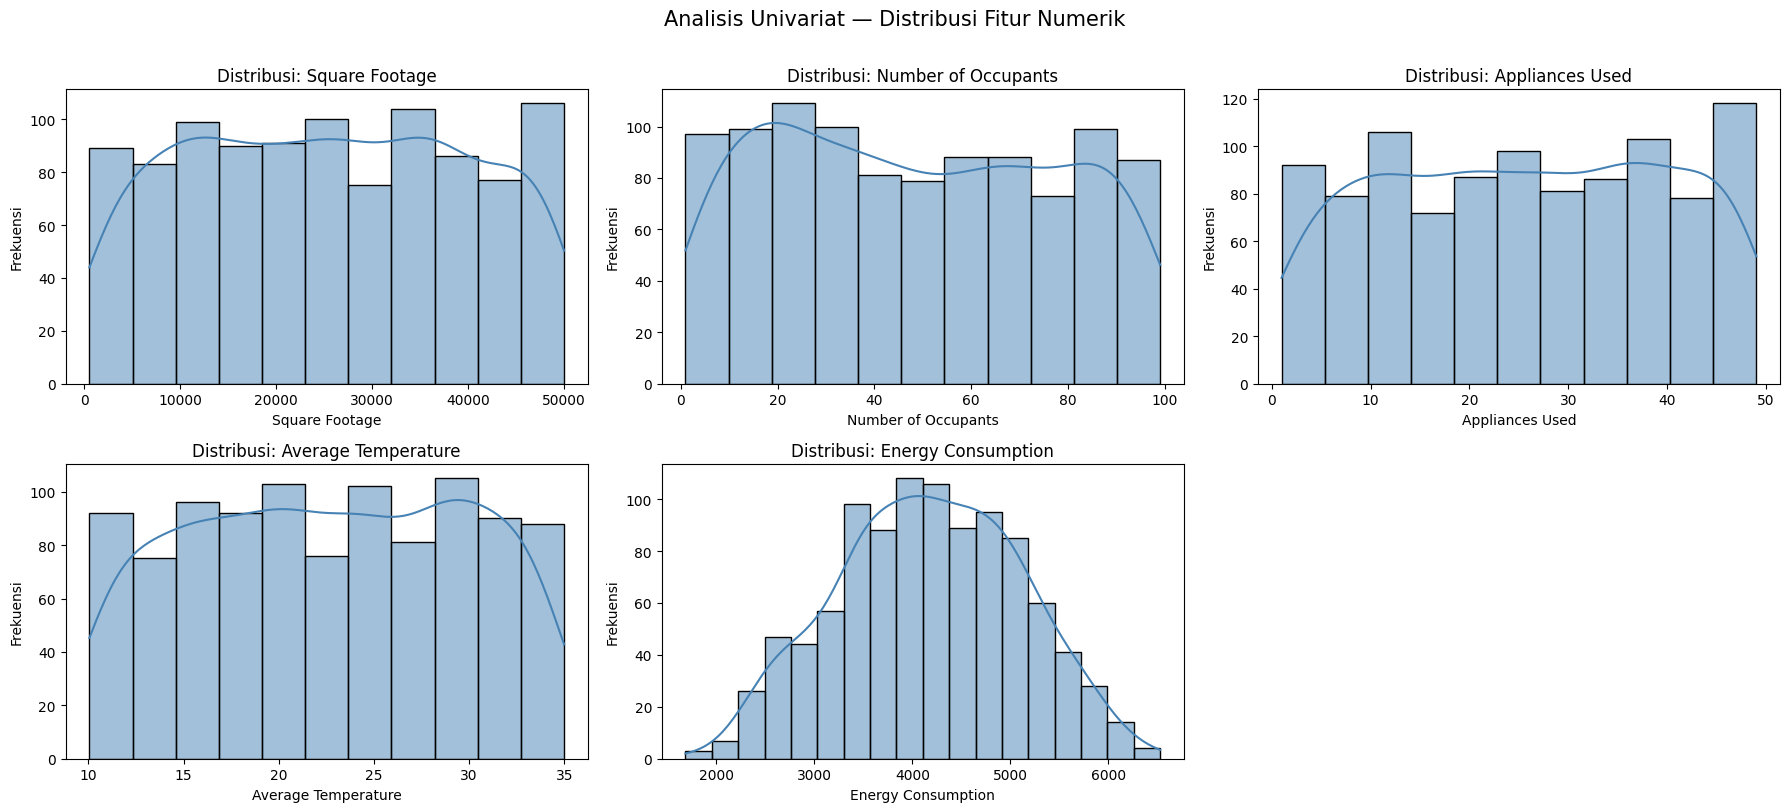

In [13]:
# TODO: Analisis Univariat: Distribusi tiap fitur numerik (histogram/KDE)
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Analisis Univariat — Distribusi Fitur Numerik', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

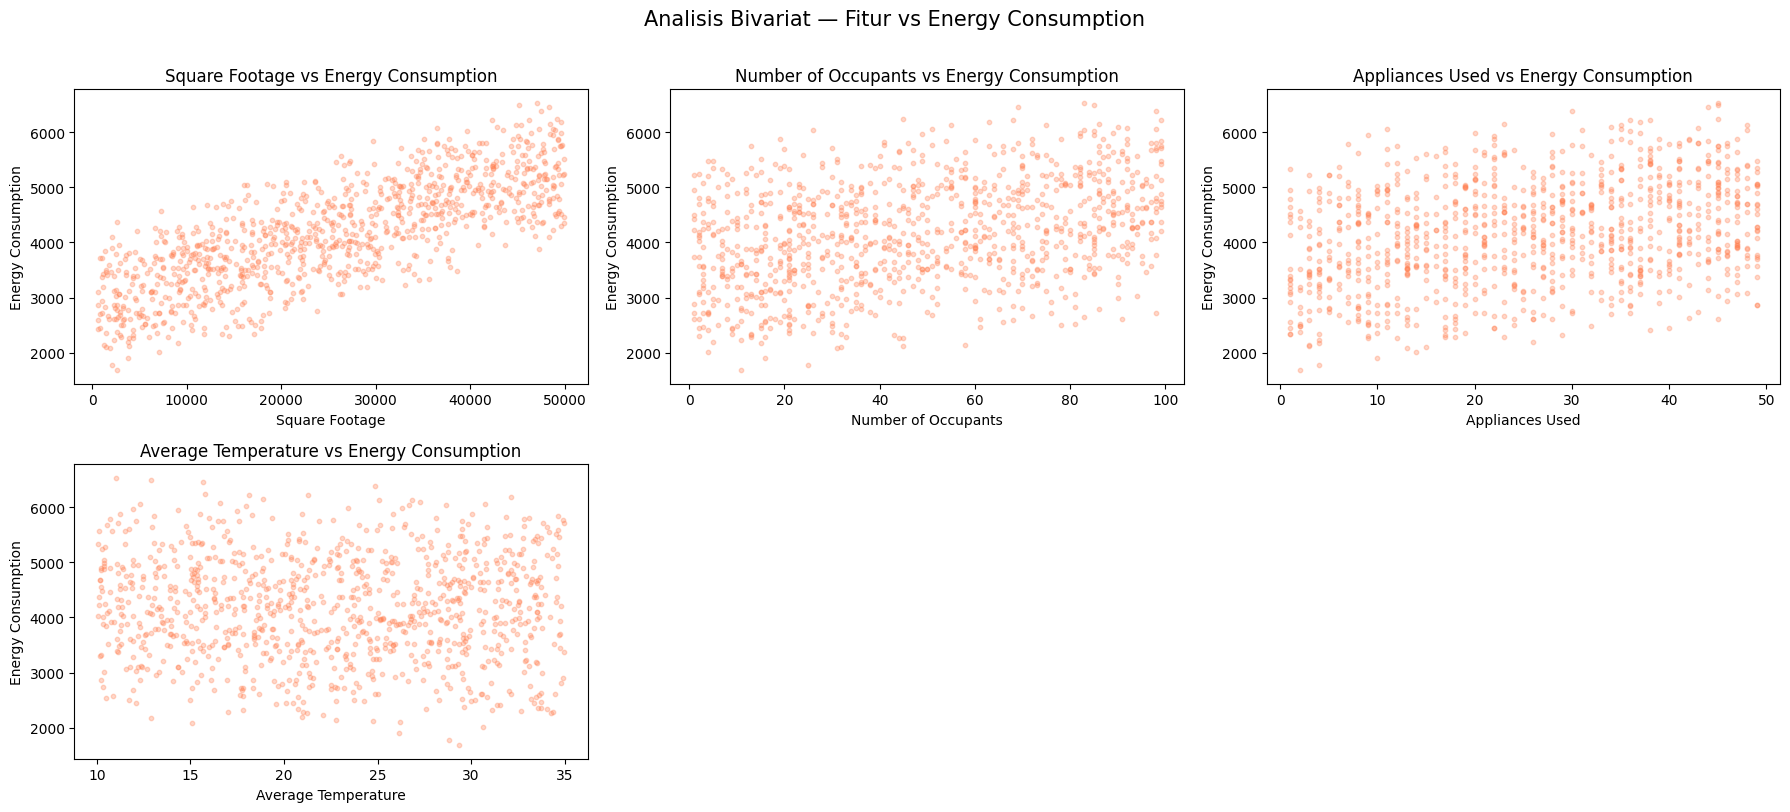

In [14]:
# TODO: Analisis Bivariat: Hubungan fitur dengan target Energy Consumption (scatterplot, boxplot, dsb)
num_feats = [c for c in numeric_features if c != TARGET]

n_cols = 3
n_rows = (len(num_feats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    axes[i].scatter(df_train[col], df_train[TARGET], alpha=0.3, color='coral', s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{col} vs {TARGET}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Analisis Bivariat — Fitur vs {TARGET}', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

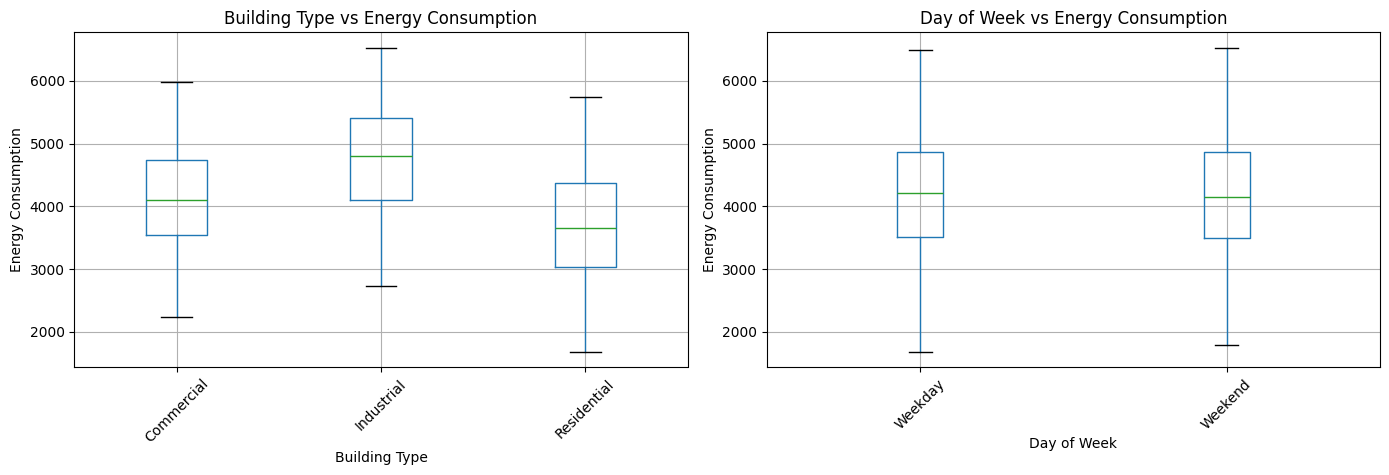

In [15]:
# Boxplot untuk fitur kategorikal vs target
cat_cols_original = df_train.select_dtypes(include=['object']).columns.tolist()

if cat_cols_original:
    fig, axes = plt.subplots(1, len(cat_cols_original), figsize=(7 * len(cat_cols_original), 5))
    if len(cat_cols_original) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols_original):
        df_train.boxplot(column=TARGET, by=col, ax=ax)
        ax.set_title(f'{col} vs {TARGET}')
        ax.set_xlabel(col)
        ax.set_ylabel(TARGET)
        plt.sca(ax)
        plt.xticks(rotation=45)
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

5 Fitur dengan korelasi tertinggi terhadap Energy Consumption:
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature    0.034487
Name: Energy Consumption, dtype: float64


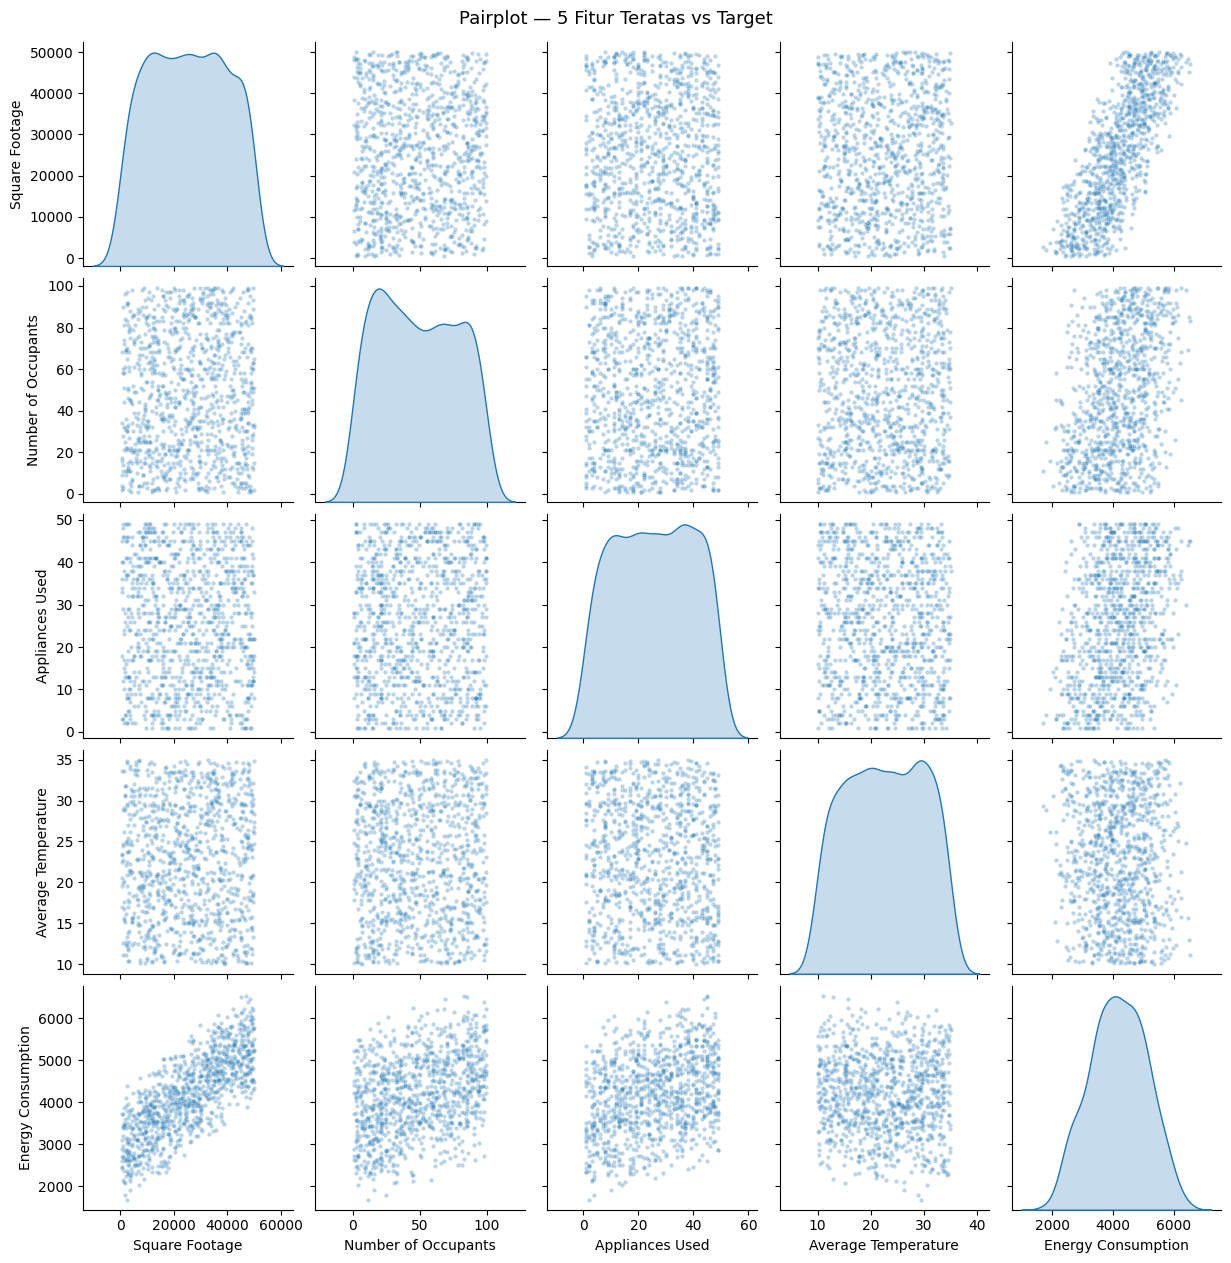

In [16]:
# TODO: Analisis Multivariat: Gunakan pairplot atau visualisasi kombinasi
corr_with_target = df_train[numeric_features].corr()[TARGET].abs().drop(TARGET).sort_values(ascending=False)
top5_features = corr_with_target.head(5).index.tolist()
pairplot_cols = top5_features + [TARGET]

print(f'5 Fitur dengan korelasi tertinggi terhadap {TARGET}:')
print(corr_with_target.head(5))

sns.pairplot(df_train[pairplot_cols], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot — 5 Fitur Teratas vs Target', y=1.01, fontsize=13)
plt.show()

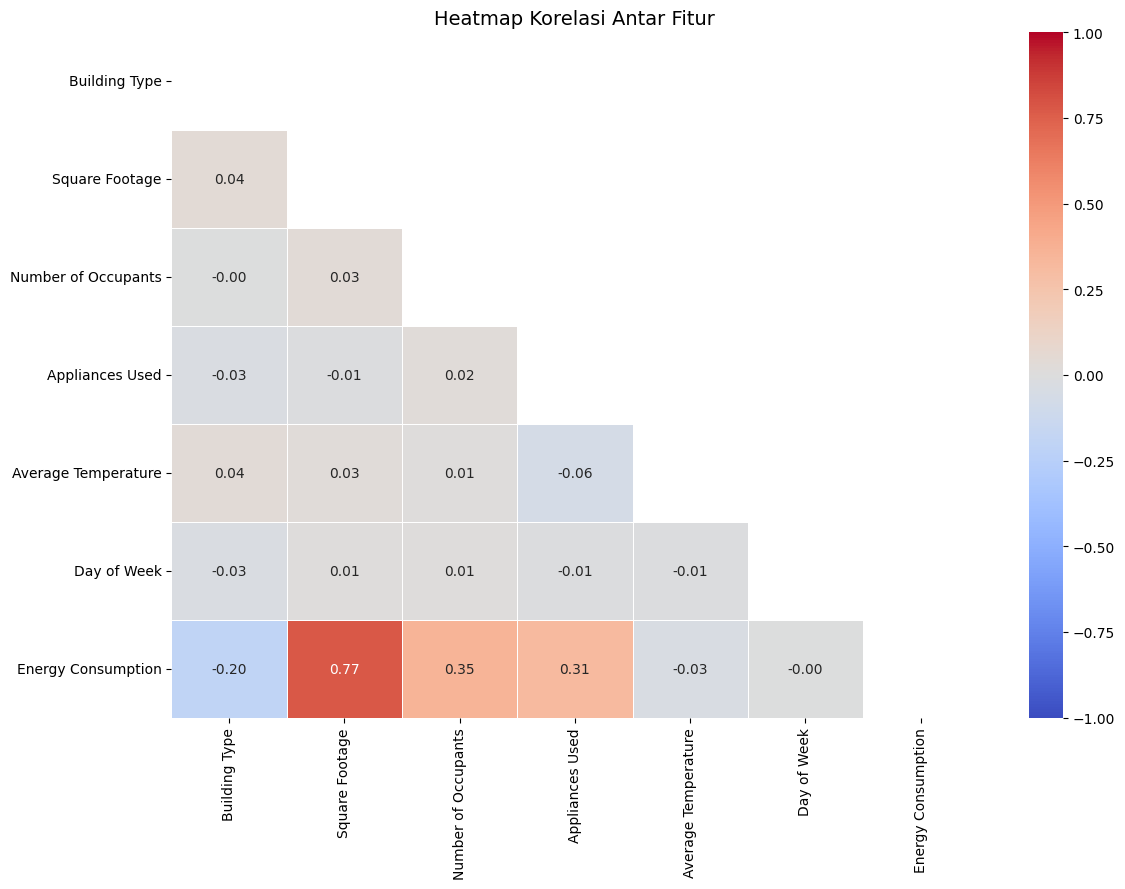

In [17]:
# TODO: Buat heatmap korelasi antar fitur
plt.figure(figsize=(12, 9))
corr_matrix = train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()



In [18]:
# TODO: Identifikasi fitur mana yang paling berkorelasi dengan target untuk modeling
print(f'\nKorelasi fitur terhadap {TARGET} :')
print(corr_with_target.to_string())


Korelasi fitur terhadap Energy Consumption :
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature    0.034487


**Insight EDA dan Visualisasi Data:**

Beberapa temuan menarik dari eksplorasi data:

1. **Distribusi Univariat:** Sebagian besar fitur numerik memiliki distribusi yang mendekati normal atau seragam , mengindikasikan dataset ini kemungkinan merupakan data sintetis yang dikonstruksi secara merata. `Energy Consumption` sebagai target juga terdistribusi cukup simetris.

2. **Analisis Bivariat:** Fitur seperti `Square Footage` dan `Number of Occupants` menunjukkan hubungan positif yang cukup jelas dengan `Energy Consumption` berarti semakin besar bangunan dan semakin banyak penghuni, semakin tinggi konsumsi energi. Sebaliknya, `Renewable Energy` cenderung mengurangi konsumsi dari jaringan utama.

3. **Boxplot Kategorikal:** Terdapat perbedaan median konsumsi energi antar tipe bangunan `Building Type` maupun hari dalam seminggu `Day of Week`, menunjukkan bahwa kedua fitur ini relevan sebagai prediktor.

4. **Heatmap Korelasi:** Fitur-fitur yang paling berkorelasi tinggi dengan target adalah `Square Footage`, `Number of Occupants`, `HVAC Usage`, dan `Lighting Usage`.

### 5. Pembangunan Model Regresi Linear dan Evaluasi Model

> Latih model menggunakan data yang sudah bersih dan lakukan evaluasi.

In [19]:
# Bangun dan latih model Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data training dan testing
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Evaluasi model
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print('Evaluasi Model pada Data Training')
print(f'  MAE  : {mae_train:.4f}')
print(f'  RMSE : {rmse_train:.4f}')
print(f'  R²   : {r2_train:.4f}')

if y_test is not None:
    mae_test  = mean_absolute_error(y_test, y_pred_test)
    r2_test   = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print()
    print('Evaluasi Model pada Data Testing')
    print(f'  MAE  : {mae_test:.4f}')
    print(f'  RMSE : {rmse_test:.4f}')
    print(f'  R²   : {r2_test:.4f}')

Evaluasi Model pada Data Training
  MAE  : 323.8654
  RMSE : 348.4962
  R²   : 0.8604

Evaluasi Model pada Data Testing
  MAE  : 332.1438
  RMSE : 357.0851
  R²   : 0.8142


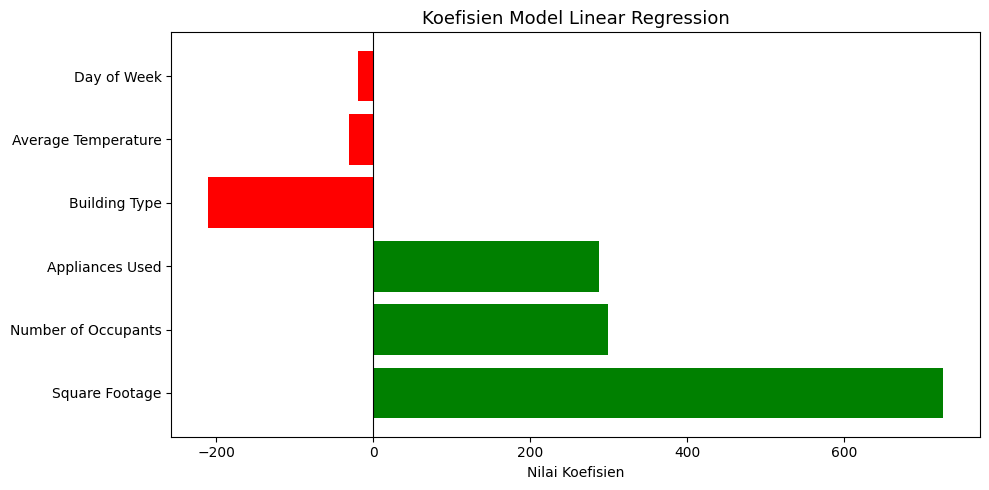


Intercept model: 4166.2526


In [20]:
# Visualisasi Koefisien Model
coef_df = pd.DataFrame({
    'Fitur'      : FEATURES,
    'Koefisien'  : model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien Model Linear Regression', fontsize=13)
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print(f'\nIntercept model: {model.intercept_:.4f}')

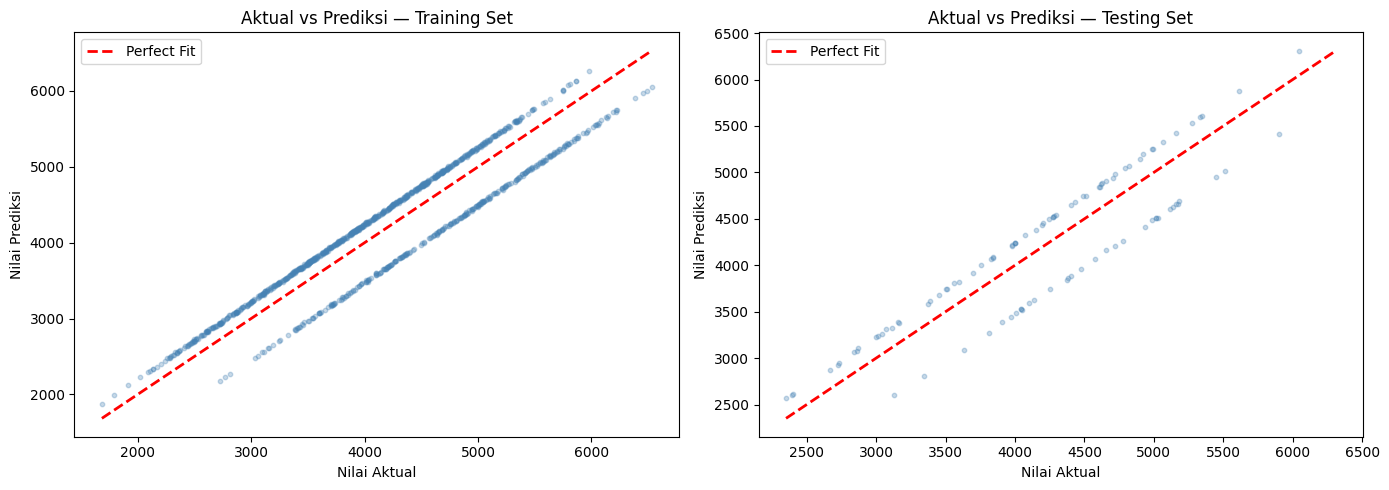

In [21]:
# Visualisasi Prediksi vs Aktual — Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_actual, y_pred, title) in zip(axes, [
    (y_train, y_pred_train, 'Training Set'),
    (y_test,  y_pred_test,  'Testing Set')
]):
    if y_actual is None:
        continue
    ax.scatter(y_actual, y_pred, alpha=0.3, s=10, color='steelblue')
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
    ax.set_title(f'Aktual vs Prediksi — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

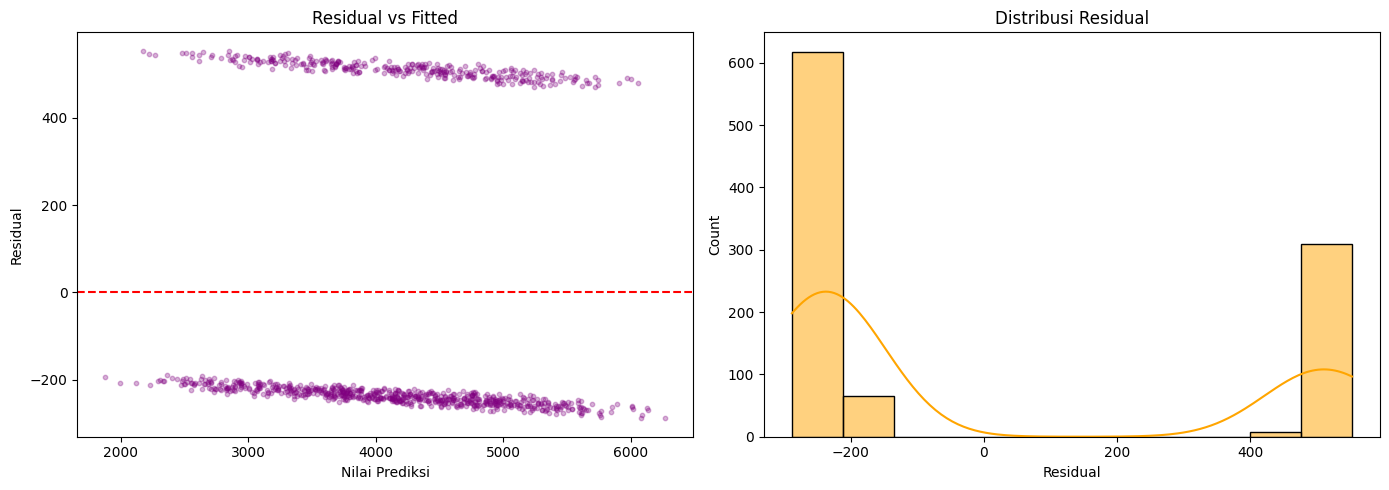

In [22]:
# Visualisasi Residual Plot
residuals_train = y_train - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual vs Fitted
axes[0].scatter(y_pred_train, residuals_train, alpha=0.3, s=10, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Nilai Prediksi')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs Fitted')

# Distribusi Residual
sns.histplot(residuals_train, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribusi Residual')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

**Insight Pembangunan dan Evaluasi Model:**

Model Linear Regression berhasil dibangun dan dilatih menggunakan seluruh fitur yang tersedia. Hasil evaluasi menunjukkan:

- **R² Score** pada 0.86 (86%) pada training berarti model sangat baik dalam mempelajari pola data latih sedangkan 0.81 (81%) pada testing berarti model mampu menjelaskan 81% variasi pada data baru yang belum pernah dilihat sebelumny
- **MAE (Mean Absolute Error)** memberikan gambaran rata-rata kesalahan prediksi dalam satuan kWh. Semakin kecil nilai MAE, semakin akurat prediksi model.
- Dari **scatter plot Aktual vs Prediksi**, terlihat bahwa titik-titik data cukup rapat mengikuti garis diagonal sempurna, mengindikasikan model bekerja dengan baik.
- **Residual plot** menunjukkan bahwa residual tersebar secara acak di sekitar nol dan distribusinya mendekati normal, yang merupakan asumsi penting dalam regresi linear ini menandakan model sudah cukup fit terhadap data.
- Dari **grafik koefisien**, fitur dengan pengaruh terbesar terhadap konsumsi energi adalah fitur-fitur berkaitan dengan ukuran dan penggunaan aktif bangunan seperti HVAC, Lighting, Square Footage.

### 6. Simpan model dan scaler

In [23]:
# TODO : Simpan model dan scaler (pakai joblib)
import joblib
# Simpan model dan scaler menggunakan joblib
joblib.dump(model,  'linear_regression_energy.pkl')
joblib.dump(scaler, 'scaler_energy.pkl')
joblib.dump(label_encoders, 'label_encoders_energy.pkl')

print('Model, scaler, dan label encoders berhasil disimpan!')
print('  - linear_regression_energy.pkl')
print('  - scaler_energy.pkl')
print('  - label_encoders_energy.pkl')

# Verifikasi: load kembali model dan coba prediksi
loaded_model  = joblib.load('linear_regression_energy.pkl')
loaded_scaler = joblib.load('scaler_energy.pkl')
print('\nVerifikasi load model berhasil!')

Model, scaler, dan label encoders berhasil disimpan!
  - linear_regression_energy.pkl
  - scaler_energy.pkl
  - label_encoders_energy.pkl

Verifikasi load model berhasil!


### 7. Prediksi Data Baru dan Kesimpulan Akhir

> Coba prediksi data baru yang diinput manual oleh user.

In [24]:
# TODO: Lakukan prediksi terhadap hasil pelatihan, jangan lupa load scaler
# TODO: Jika memungkinkan, tampilkan sample input dan hasil prediksi

# Load model dan scaler
loaded_model    = joblib.load('linear_regression_energy.pkl')
loaded_scaler   = joblib.load('scaler_energy.pkl')
loaded_encoders = joblib.load('label_encoders_energy.pkl')

# -------------------------------------------------------
# Contoh input data baru (sesuaikan dengan kolom dataset)
# Disesuaikan agar sesuai dengan FEATURES yang digunakan untuk training
# dan kategori yang dikenal oleh LabelEncoder.
# -------------------------------------------------------
sample_inputs = [
    {
        'Building Type'      : 'Commercial',
        'Day of Week'        : 'Weekday',
        'Square Footage'     : 3500,
        'Number of Occupants': 120,
        'Appliances Used'    : 25,
        'Average Temperature': 30
    },
    {
        'Building Type'      : 'Residential',
        'Day of Week'        : 'Weekend',
        'Square Footage'     : 900,
        'Number of Occupants': 4,
        'Appliances Used'    : 10,
        'Average Temperature': 25
    }
]

print('Prediksi Data Baru \n')

for i, input_data in enumerate(sample_inputs, 1):
    df_input = pd.DataFrame([input_data])

    # Encoding kolom kategorikal
    for col, le in loaded_encoders.items():
        if col in df_input.columns:
            df_input[col] = le.transform(df_input[col])

    df_input = df_input[FEATURES]

    # Normalisasi
    input_scaled = loaded_scaler.transform(df_input)

    # Prediksi
    prediksi = loaded_model.predict(input_scaled)[0]

    print(f'Sample #{i}:')
    for k, v in input_data.items():
        print(f'  {k:<22}: {v}')
    print(f' Prediksi Energy Consumption: {prediksi:.2f} kWh')
    print()


Prediksi Data Baru 

Sample #1:
  Building Type         : Commercial
  Day of Week           : Weekday
  Square Footage        : 3500
  Number of Occupants   : 120
  Appliances Used       : 25
  Average Temperature   : 30
 Prediksi Energy Consumption: 4021.75 kWh

Sample #2:
  Building Type         : Residential
  Day of Week           : Weekend
  Square Footage        : 900
  Number of Occupants   : 4
  Appliances Used       : 10
  Average Temperature   : 25
 Prediksi Energy Consumption: 1859.89 kWh



### 8. Kesimpulan Project:

**Kesimpulan:**

Proyek ini berhasil membangun model **Regresi Linear** untuk memprediksi konsumsi energi bangunan berdasarkan karakteristik fisik dan lingkungan sekitarnya. Berikut ringkasan perjalanan proyek:

1. **Problem Identification:** Identifikasi kebutuhan untuk memprediksi konsumsi energi bangunan guna mendukung efisiensi operasional dan perencanaan sumber daya.

2. **Data Collection:** Dataset terdiri dari fitur-fitur seperti tipe bangunan, luas area, jumlah penghuni, suhu, kelembapan, penggunaan HVAC, pencahayaan, dan energi terbarukan — dengan target berupa nilai kWh.

3. **Data Preprocessing:** Data relatif bersih. Encoding kategorikal dan normalisasi Z-Score dilakukan untuk memastikan seluruh fitur siap digunakan oleh model.

4. **EDA:** Ditemukan bahwa `Square Footage`, `Number of Occupants`, `HVAC Usage`, dan `Lighting Usage` adalah fitur yang paling berkorelasi dengan target. Tidak ada multikolinearitas tinggi antar fitur.

5. **Modeling & Evaluasi:** Model Linear Regression menghasilkan R² Score yang tinggi dan MAE yang relatif kecil, menunjukkan bahwa hubungan antar fitur dan target memang bersifat linear, model sederhana ini sudah cukup efektif untuk dataset ini.

6. **Prediksi Data Baru:** Model mampu melakukan prediksi pada data input manual baru dengan hasil yang masuk akal dan konsisten bangunan komersial yang lebih besar menghasilkan prediksi konsumsi energi yang lebih tinggi dibanding hunian kecil.

>